In [1]:
## init mongo db and fiftyone connection
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
## Load dataset and views from mongodb 
dataset = fo.load_dataset("dugong")

## load the views
nc_view = dataset.load_saved_view("nc")
wp_view = dataset.load_saved_view("wp")

In [3]:
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import umap
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE 
import fiftyone.brain as fob
from sklearn.preprocessing import normalize
import plotly.express as px
import skdim
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import ot
from sklearn.manifold import TSNE
import cv2
from fiftyone import ViewField as F
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
import random

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import pairwise_distances

## renders plotly properly in a html instance. 
import plotly.io as pio
pio.renderers.default = "notebook"


In [4]:
## get embeddings for each view and normalize it 
nc_emb = nc_view.values("full_embeddings")
wp_emb = wp_view.values("full_embeddings")

## convert to array
nc_emb = np.array(nc_emb)
wp_emb = np.array(wp_emb)

## normalize firsrt
nc_norm = normalize(nc_emb)
wp_norm = normalize(wp_emb)

## CREATE VIEWS OF THE DATASET THAT ARE REPRESENTATIVE OF GEOGRAPHICAL LOCATIONS
## NOTE : Mantasandy is being excluded from further analysis because
## it only has 3 images inside the folder. 

# view_GAM = wp_view.match(
#     F("subregion")=="GAM"
# )
# view_FRIWEN = wp_view.match(
#     F("subregion")=="FRIWEN"
# )
# view_MANTASANDY = wp_view.match(
#     F("subregion")=="MANTASANDY"
# )
# view_UM = wp_view.match(
#     F("subregion")=="UM"
# )
# gam_emb = view_GAM.values('full_embeddings')
# friwen_emb = view_FRIWEN.values('full_embeddings')
# um_emb = view_UM.values('full_embeddings')

# norm_gam_emb = normalize(gam_emb)
# norm_friwen_emb = normalize(friwen_emb)
# norm_um_emb = normalize(um_emb)

# print("Number of images per geographical location")
# print(f"WP- GAM: {len(view_GAM)}")
# print(f"WP - FRIWEN: {len(view_FRIWEN)}")
# print(f"WP - MANTASANDY: {len(view_MANTASANDY)}")
# print(f"WP -UM: {len(view_UM)}")
# print(f"NC: {len(nc_view)}")
# print(f"WP (total): {len(wp_view)}")

# datasets_l ={'WP': wp_norm, 
#              'NC' : nc_norm,
#             'WP_GAM':norm_gam_emb,
#             'WP_friwen':norm_friwen_emb,
#             'WP_mant':norm_um_emb}



In [6]:
## get the train 
dataset.distinct('tags')

['test_41', 'test_50', 'train_41', 'train_50', 'val_41', 'val_50']

In [19]:
train_wp = wp_view.match(F('tags').contains("train_41"))

wp_train_emb = train_wp.values('full_embeddings')
wp_train_emb_norm = normalize(wp_train_emb)

In [55]:
len(train_wp)*.05

71.2

### Uniqueness (weighted)

In [ ]:
# Weighted Uniqueness
# closer neighboors has a higher weight than further 

def compute_weighted_uniqueness(embeddings, 
                                weights=[0.9, 0.6, 0.3, 0.1]):
    k = len(weights)
    
    # knn
    #  look for k+1 because the 1st neighbor is always the point itself (dist=0)
    knn = NearestNeighbors(n_neighbors=k + 1,
                            metric='cosine')
    knn.fit(embeddings)
    
    # extract distances
    # distances shape: (num_samples, k+1)
    distances, _ = knn.kneighbors(embeddings)
    
    # apply the Weights [0.6, 0.3, 0.1]
    # here we slice dists[:, 1:] to ignore the 0-distance to self
    relevant_dists = distances[:, 1:]
    
    # weighted mean
    weighted_dists = np.mean(relevant_dists * weights,
                            axis=1
                            )
    
    # normalize to [0, 1]
    if weighted_dists.max() > 0:
        weighted_dists /= weighted_dists.max()
        
    return weighted_dists

In [21]:
## compute uniqueness and plot results
uniqueness = compute_weighted_uniqueness(wp_train_emb_norm,
                                         weights = [0.9,0.6,0.3,0.1]
                                         )

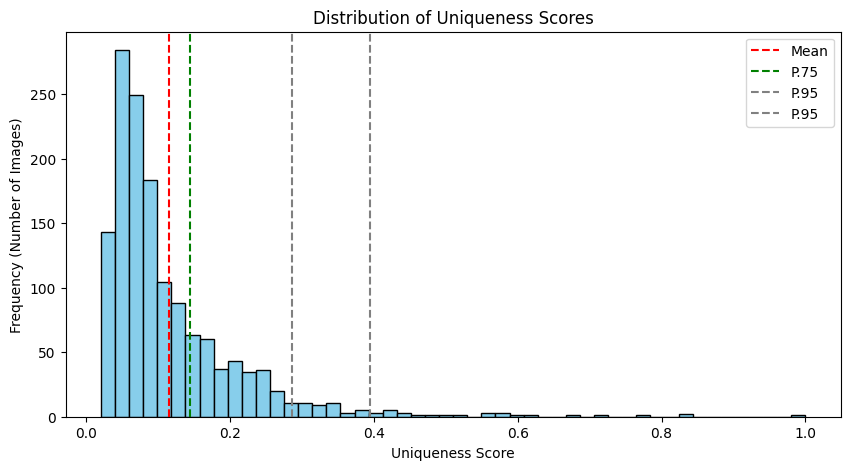

In [44]:
def plot_uniqueness_distribution(uniqueness_scores):
    plt.figure(figsize=(10, 5))
    plt.hist(uniqueness_scores, bins=50, color='skyblue', edgecolor='black')
    plt.axvline(np.mean(uniqueness_scores), color='red', linestyle='dashed', label='Mean')
    plt.axvline(np.percentile(uniqueness_scores, q=75.),color='green',linestyle='dashed',label='P.75')
    plt.axvline(np.percentile(uniqueness_scores, q=95),color='gray',linestyle='dashed',label='P.95')
    plt.axvline(np.percentile(uniqueness_scores, q=98),color='gray',linestyle='dashed',label='P.95')
    plt.title("Distribution of Uniqueness Scores")
    plt.xlabel("Uniqueness Score")
    plt.ylabel("Frequency (Number of Images)")
    plt.legend()
    plt.show()

plot_uniqueness_distribution(uniqueness)

In [104]:
(uniqueness >np.percentile(uniqueness,75)).sum()

np.int64(356)

In [ ]:

def selector_num_uniqueness(partition_size:float, 
                            wp_train_length:int , 
                            uniqueness:np.array,
                            ratio_cluster_uniqueness:float = 0.5
                            ):
    """
    Find the number of uniqueness subset to compound the best subset for the given training partition.
    It looks first at the number of images which should compose the training partition.
    As an example, if partition is 10% and the train size is 1000 images, given the ratio as 50% which means 
    the same amount compounding the cluster and the uniqueness, 500 images coming from cluster and 500 images coming 
    from uniqueness. 

    Args:
        ratio_cluster_uniqueness: float. The ratio of uniqueness:cluster If 1:1 so 0.5. If 1:2 so 0.33, if 1:3 so 0.25. 
    """
    import math
    len_uniq_images = math.floor(partition_size*wp_train_length*ratio_cluster_uniqueness)
    print(f"Length of the uniqueness image size list for the given partition:{len_uniq_images}")

    # loop through this space checking if the amount is within the fuzzy_border
    diff_list = []
    percentiles = np.array([0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.90,0.92,0.93,0.94,
                                0.95,0.96,0.97,0.98,0.99])[::-1] #reverse order
    for percentile in percentiles:
        num_images_percent = (uniqueness >np.percentile(uniqueness,percentile*100)).sum()
        diff = np.abs(len_uniq_images-num_images_percent)
        diff_list.append(diff)

    #print(np.argmin(np.array(diff_list)))
    perc_out = percentiles[np.argmin(np.array(diff_list))]
    print(f"Percentile choosen:{perc_out*100}")
    print(f"number of images:{(uniqueness >np.percentile(uniqueness,perc_out*100)).sum()}")
    
    return perc_out*100




    

percentile_representative = selector_num_uniqueness(
    partition_size=0.05,
    wp_train_length=len(train_wp),
    uniqueness=uniqueness,
    ratio_cluster_uniqueness=0.5
)

## select the images from the training set that contains this percentile

Length of the uniqueness image size list for the given partition:35
Percentile choosen:98.0
number of images:29


np.float64(98.0)

In [40]:
def plot_uniqueness_landscape(coords_2d_pca,
                              coords_2d_umap, 
                              coords_2d_tsne, 
                                uniqueness_scores,
                                figsize=(12,8),
                                title = "None"
                            ):
    fig, axes = plt.subplots(ncols=3, figsize = figsize)
    axes = axes.flatten()

    # left side is PCA 
    axes[0].scatter(
        coords_2d_pca[:, 0], 
        coords_2d_pca[:, 1], 
        c=uniqueness_scores, 
        cmap='inferno_r', 
        s=15, 
        alpha=0.7
    )
    
    axes[0].set_xlabel("PCA 1")
    axes[0].set_ylabel("PCA 2")
    
    axes[1].scatter(
        coords_2d_umap[:,0],
        coords_2d_umap[:,1],
        c =uniqueness_scores,
        cmap='inferno_r',
        s=15,
        alpha=0.7
    )

    axes[1].set_xlabel("UMAP 1")
    axes[1].set_ylabel("UMAP 2")

    axes[2].scatter(
        coords_2d_tsne[:,0],
        coords_2d_tsne[:,1],
        c =uniqueness_scores,
        cmap='inferno_r',
        s=15,
        alpha=0.7
    )

    axes[2].set_xlabel("TSNE 1")
    axes[2].set_ylabel("TSNE 2")

    cbar = fig.colorbar(axes[2].collections[0],
                         ax=axes,
                           orientation='vertical',
                            fraction=0.02,
                              pad=0.04)
    #axes[1].set_c
    # Add a colorbar to explain the scale
    cbar.set_label('Uniqueness', rotation=270, labelpad=15)
    
    fig.suptitle(title, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.3)
    ##plt.tight_layout()
    plt.show()



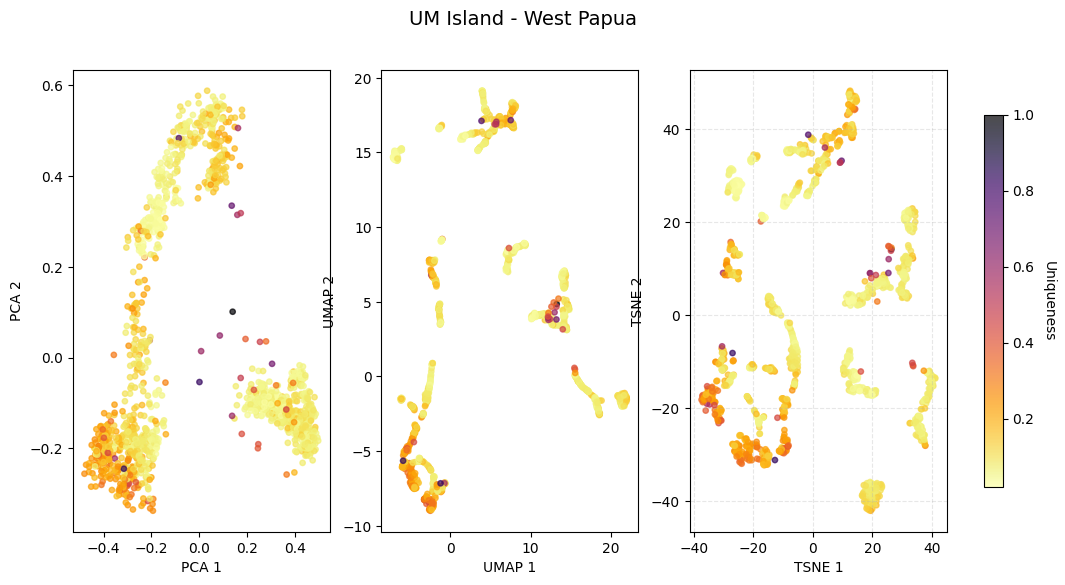

In [ ]:
## PLOT uniqueness with PCA reduction
## pca_2d
pca_2d = PCA(n_components=2)
coords_2d_pca = pca_2d.fit_transform(wp_train_emb_norm)

## using UMAP norm_gam_emb
reducer = umap.UMAP(n_neighbors=30, 
                    n_epochs=500,
                    min_dist=0.2, 
                    metric='cosine', 
                    init='pca',
                    random_state=42
                    )
coords_2d_umap = reducer.fit_transform(wp_train_emb_norm)  

## calculating tsne
tsne = TSNE(n_components=2, 
            random_state=0, 
            perplexity=30,
            metric='cosine',
            init='pca')
coords_2d_tsne = tsne.fit_transform(wp_train_emb_norm)
#  
plot_uniqueness_landscape(coords_2d_pca,
                            coords_2d_umap,
                            coords_2d_tsne,
                            uniqueness_scores = uniqueness,
                            figsize=(12,6),
                            title="WP Train - seed 38")

## REPRESENTATIVES - KMEANS

In [115]:
import numpy as np

def get_diverse_stochastic_representatives(embeddings, 
                                           labels, 
                                           centroids, 
                                           n_clusters, 
                                           c_per_cluster, 
                                           temperature=0.5, 
                                           seed=42):
    """
    Selects representative samples from clusters using a temperature-scaled 
    Softmax distribution to balance representation and diversity.

    Instead of a 'greedy' selection (always picking the closest sample), this 
    function assigns a probability to each sample in a cluster based on its 
    proximity to the centroid. A 'Temperature' parameter controls the randomness.

    Args:
        embeddings (np.ndarray): Normalized feature vectors (N, D).
        labels (np.ndarray): Cluster assignment for each sample (N,).
        centroids (np.ndarray): Coordinates of the cluster centers (K, D).
        n_clusters (int): Number of clusters (K).
        c_per_cluster (int): Number of samples to select from each cluster.
        temperature (float): Controls selection strictly. 
            - T -> 0: Approaches 'greedy' selection (closest to centroid).
            - T -> 1: Follows the natural distribution of distances.
            - T -> infinity: Approaches 'random' uniform sampling.
        seed (int): Random seed for reproducibility.

    Returns:
        np.ndarray: Indices of the selected representative samples.
    """
    representative_indices = []
    rng = np.random.default_rng(seed)

    for i in range(n_clusters):
        # 1. Isolate indices of samples belonging to the current cluster
        cluster_indices = np.where(labels == i)[0]
        if len(cluster_indices) == 0:
            continue
        
        # 2. Calculate L2 distances from the Centroid to all points in the cluster
        # Even with Cosine metric, Euclidean distance on normalized vectors works perfectly
        dists = np.linalg.norm(embeddings[cluster_indices] - centroids[i], axis=1)
        
        # 3. Compute Softmax-based probabilities
        # We use (-distances) because smaller distances should have higher probability.
        # Scaling by 'temperature' stretches or flattens the probability distribution.
        weights = np.exp(-dists / temperature)
        probs = weights / np.sum(weights)
        
        # 4. Stochastic Sampling
        # size: Number of samples to pick (cannot exceed cluster size)
        # replace=False: Ensures we pick unique images
        n_to_pick = min(len(cluster_indices), c_per_cluster)
        chosen_in_cluster = rng.choice(
            len(cluster_indices), 
            size=n_to_pick, 
            replace=False, 
            p=probs
        )
        
        # Map local cluster indices back to original dataset indices
        representative_indices.extend(cluster_indices[chosen_in_cluster])
    
    return np.array(representative_indices)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP  # Ensure umap-learn is installed
from sklearn.preprocessing import normalize

def plot_active_learning_landscape(coords_pca, coords_umap, coords_tsne, labels, selected_idx, figsize=(18, 6), title="Selection Landscape"):
    fig, axes = plt.subplots(ncols=3, figsize=figsize)
    
    titles = ["PCA (Linear)", "UMAP (Topological)", "t-SNE (Local)"]
    coords = [coords_pca, coords_umap, coords_tsne]
    
    for i, ax in enumerate(axes):
        # Plot the "Background" (All samples colored by cluster)
        scatter = ax.scatter(
            coords[i][:, 0], 
            coords[i][:, 1], 
            c=labels, 
            cmap='tab10', 
            s=20, 
            alpha=0.4,
            edgecolors='none'
        )
        
        # Highlight the Selected Representatives (The "Leverage" points)
        ax.scatter(
            coords[i][selected_idx, 0], 
            coords[i][selected_idx, 1], 
            c='red', 
            marker='*', 
            s=120, 
            edgecolor='black', 
            linewidth=0.8,
            label='Selected'
        )
        
        ax.set_title(titles[i])
        ax.set_xlabel("Comp 1")
        ax.set_ylabel("Comp 2")
        ax.grid(True, linestyle='--', alpha=0.3)

    fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


def active_learning_kmeans_pipeline(embeddings_norm, 
                                       n_clusters=6, 
                                       samples_per_cluster=2, 
                                       temperature=0.5, 
                                       random_seed=42):
    """
    Clustering -> Stochastic Selection -> Multi-Projection Plotting.
    
    Args:
        embeddings:np.array. Should be normalized. Use sklearn.preprocessing.normalize
    Returns:
        selected_indices (np.ndarray): Indices of the samples to be tagged in FiftyOne.
    """
    # 1. Clustering
    kmeans = KMeans(n_clusters=n_clusters, 
                    init='k-means++', 
                    n_init=10, 
                    random_state=random_seed
                    )
    cluster_labels = kmeans.fit_predict(embeddings_norm)
    centroids = kmeans.cluster_centers_

    # 2. Stochastic Representative Selection
    selected_indices = get_diverse_stochastic_representatives(
        embeddings_norm, 
        cluster_labels, 
        centroids, 
        n_clusters, 
        samples_per_cluster, 
        temperature=temperature,
        seed=random_seed
    )

    # Compute Dimensionality Reductions
    print("Computing Dimensionality Reductions (PCA, UMAP, t-SNE)...")
    pca_coords  = PCA(n_components=2, random_state=random_seed).fit_transform(embeddings_norm)
    umap_coords = UMAP(n_components=2, random_state=random_seed).fit_transform(embeddings_norm)
    tsne_coords = TSNE(n_components=2, random_state=random_seed).fit_transform(embeddings_norm)

    # Visualization
    # We color points by Cluster ID to see the manifold structure
    plot_active_learning_landscape(
        pca_coords, 
        umap_coords, 
        tsne_coords, 
        cluster_labels, 
        selected_indices,
        title=f"Active Learning Selection (K={n_clusters}, C={samples_per_cluster}, T={temperature})"
    )

    return selected_indices




Computing Dimensionality Reductions (PCA, UMAP, t-SNE)...


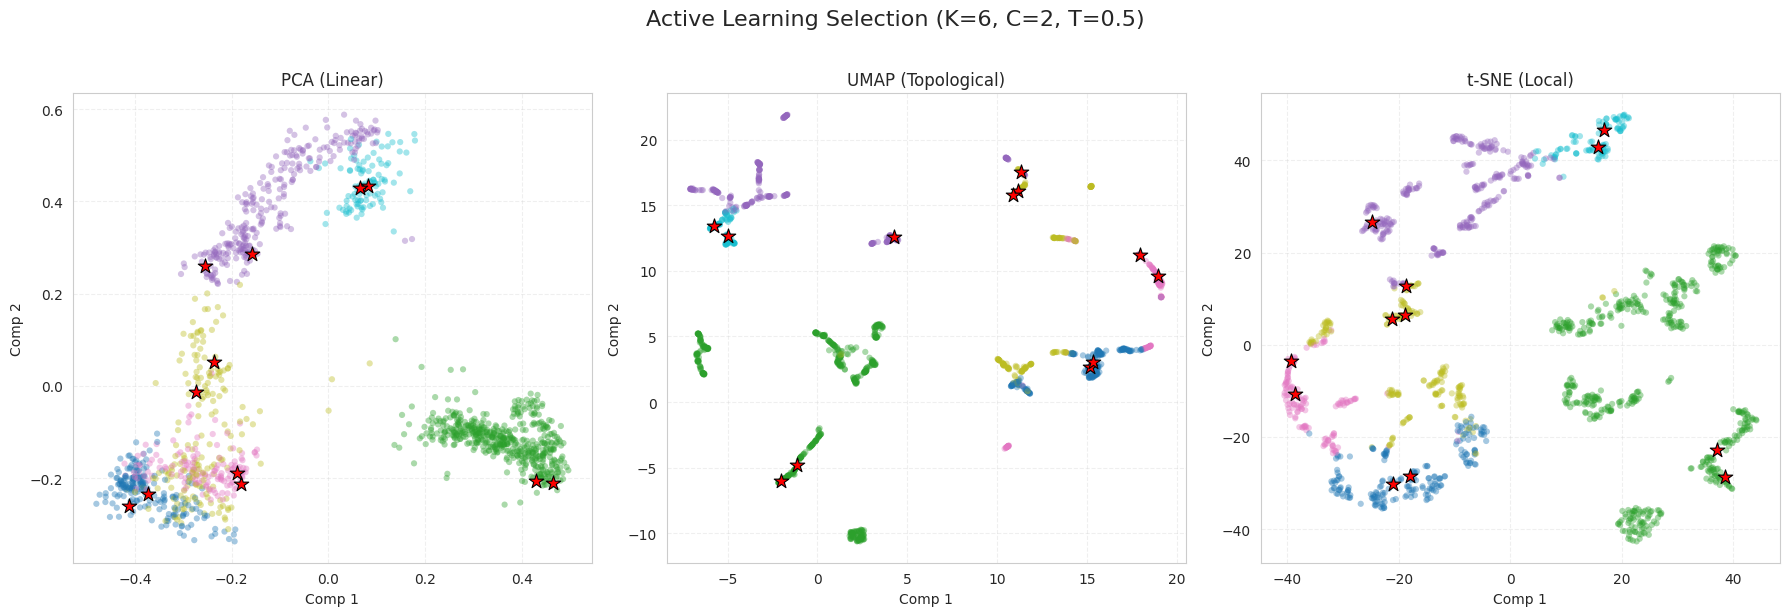

array([ 664,  577, 1344, 1260,   35,  432,  837,  843,  391,  511,  120,
        345])

In [ ]:
selected_indices = active_learning_kmeans_pipeline(wp_train_emb_norm, 
                                    n_clusters=6, 
                                    samples_per_cluster=2, 
                                    temperature=0.5, 
                                    random_seed=42)

## FULL PIPELINE

In [ ]:
import matplotlib.gridspec as gridspec

def plot_uniqueness_to_ax(ax, uniqueness_scores):
    ax.hist(uniqueness_scores, bins=50, color='skyblue', edgecolor='black')
    ax.axvline(np.mean(uniqueness_scores), color='red', linestyle='dashed', label='Mean')
    ax.axvline(np.percentile(uniqueness_scores, q=95), color='gray', linestyle='dashed', label='P.95')
    ax.set_title("Uniqueness Score Distribution")
    ax.set_xlabel("Score")
    ax.set_ylabel("Frequency")
    ax.legend()

def plot_landscape_to_axes(axes, coords_list, labels, uniq_idx, km_idx):
    names = ["PCA (Linear)", "UMAP (Topology)", "t-SNE (Local)"]
    for i, ax in enumerate(axes):
        ax.scatter(coords_list[i][:, 0], coords_list[i][:, 1], c='lightgrey', s=10, alpha=0.2)
        # cluster 
        ax.scatter(coords_list[i][km_idx, 0], coords_list[i][km_idx, 1], 
                   c='cyan', marker='o', s=30, edgecolor='black', label='Cluster Reps')
        # uniqueness outliers
        ax.scatter(coords_list[i][uniq_idx, 0], coords_list[i][uniq_idx, 1], 
                   c='magenta', marker='*', s=60, edgecolor='black', label='Uniqueness')
        ax.set_title(names[i])
        ax.grid(True, linestyle='--', alpha=0.3)

In [ ]:
import math 

import matplotlib.gridspec as gridspec
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

def plot_uniqueness_to_ax(ax, uniqueness_scores):
    ax.hist(uniqueness_scores, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
    ax.axvline(np.mean(uniqueness_scores), color='red', linestyle='dashed', label='Mean')
    ax.axvline(np.percentile(uniqueness_scores, q=95), color='gray', linestyle='dashed', label='P.95')
    ax.set_title("Uniqueness Distribution (Outlier Detection)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Uniqueness Score")
    ax.set_ylabel("Frequency")
    ax.legend()


def plot_landscape_to_axes(axes, coords_list, labels, uniq_idx, km_idx):
    names = ["PCA (Linear Partition)", "UMAP (Global Topology)", "t-SNE (Local Clusters)"]
    for i, ax in enumerate(axes):
        # Background: All potential candidates
        ax.scatter(coords_list[i][:, 0], coords_list[i][:, 1], c='lightgrey', s=8, alpha=0.15)
        
        # 1. Cluster Representatives (The "Diversity" picks)
        ax.scatter(coords_list[i][km_idx, 0], coords_list[i][km_idx, 1], 
                   c='cyan', marker='o', s=35, edgecolor='black', linewidth=0.5)
        
        # 2. Uniqueness Outliers (The "Informative" picks)
        ax.scatter(coords_list[i][uniq_idx, 0], coords_list[i][uniq_idx, 1], 
                   c='magenta', marker='*', s=80, edgecolor='black', linewidth=0.5)
        
        ax.set_title(names[i], fontsize=12)
        ax.set_xticks([]); ax.set_yticks([]) # Clean look for manifolds
        ax.grid(True, linestyle='--', alpha=0.2)


def save_consolidated_active_learning_report(uniqueness_scores, 
                                            coords_list, 
                                            labels, 
                                            uniq_idx, 
                                            km_idx, 
                                            filename="AL_Report.png"):
    
    # Calculate counts for the report header
    n_uniq = len(uniq_idx)
    n_km = len(km_idx)
    n_total = len(set(uniq_idx) | set(km_idx)) # Unique union count

    fig = plt.figure(figsize=(20, 14))
    gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1.4]) 

    # --- TOP ROW: Distribution ---
    ax_top = fig.add_subplot(gs[0, :]) 
    plot_uniqueness_to_ax(ax_top, uniqueness_scores)

    # --- BOTTOM ROW: Projections ---
    axes_bottom = [fig.add_subplot(gs[1, i]) for i in range(3)]
    plot_landscape_to_axes(axes_bottom, coords_list, labels, uniq_idx, km_idx)

    # --- HEADER & METADATA ---
    fig.suptitle("Active Learning Selection Pipeline Report", fontsize=24, fontweight='bold', y=0.98)
    
    # Text box with selection statistics
    stats_text = (
        f"Selection Summary:\n"
        f"------------------\n"
        f"Total Partition Size: {n_total} samples\n"
        f"K-Means (Diversity): {n_km} samples (●)\n"
        f"Uniqueness (Outliers): {n_uniq} samples (★)"
    )
    fig.text(0.02, 0.93, stats_text, fontsize=14, family='monospace', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=1'))

    # --- CUSTOM LEGEND ---
    # Create manual legend elements
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='K-Means (Cluster Medoids)',
               markerfacecolor='cyan', markeredgecolor='black', markersize=10),
        Line2D([0], [0], marker='*', color='w', label='Uniqueness (High-Density Outliers)',
               markerfacecolor='magenta', markeredgecolor='black', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='Unselected Manifold',
               markerfacecolor='lightgrey', alpha=0.4, markersize=8)
    ]
    
    # Place legend centrally below the manifolds
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=12, frameon=True, bbox_to_anchor=(0.5, 0.05))

    plt.tight_layout(rect=[0, 0.08, 1, 0.92]) 
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Final report generated: {filename}")


def plot_consolidated_landscape(pca, 
                                umap, 
                                tsne, 
                                uniq_idx, 
                                km_idx, 
                                title):
    """
    Visualizes the entire manifold with two distinct colors for selection types.
    """
    fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
    coords = [pca, umap, tsne]
    names = ["PCA", "UMAP", "t-SNE"]
    
    for i, ax in enumerate(axes):
        # Background
        ax.scatter(coords[i][:, 0], coords[i][:, 1], c='lightgrey', s=10, alpha=0.3)
        
        # Plot K-Means representatives (Cluster structure)
        ax.scatter(coords[i][km_idx, 0], coords[i][km_idx, 1], 
                   c='cyan', marker='o', s=40, edgecolor='black', label='Cluster Reps')
        
        # Plot Uniqueness representatives (Outliers)
        ax.scatter(coords[i][uniq_idx, 0], coords[i][uniq_idx, 1], 
                   c='magenta', marker='*', s=70, edgecolor='black', label='Uniqueness Outliers')
        
        ax.set_title(names[i])
        ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


def active_learning_pipeline(
    embeddings_norm,
    partition_size: float,
    ratio_cluster_uniqueness: float = 0.5,
    n_clusters: int = 10,
    temperature: float = 0.5,
    seed_number: int = 42
):
    """
    Active Learning Pipeline:
    1. Computes Weighted Uniqueness Scores.
    2. Determines optimal threshold to meet partition size.
    3. Selects 'Outlier' samples via Uniqueness.
    4. Selects 'Representative' samples via Stochastic K-Means.
    5. Visualizes the selection landscape.
    
    Returns:
        combined_indices (list): Final list of indices for FiftyOne selection.
    """
    total_samples = len(embeddings_norm)
    target_total_count = math.floor(partition_size * total_samples)
    
    print(f"--- Starting Pipeline (Target Subset Size: {target_total_count}) ---")

    # 1. Compute Uniqueness
    uniqueness_scores = compute_weighted_uniqueness(embeddings_norm)
    plot_uniqueness_distribution(uniqueness_scores)

    # 2. Determine Number of Uniqueness vs. Clustering images
    # budget_uniqueness = total_target * ratio (e.g. 500 = 1000 * 0.5)
    target_uniq_count = math.floor(target_total_count * ratio_cluster_uniqueness)
    
    # Use your selector to find the best percentile threshold
    chosen_percentile = selector_num_uniqueness(
        partition_size=partition_size,
        wp_train_length=total_samples,
        uniqueness=uniqueness_scores,
        ratio_cluster_uniqueness=ratio_cluster_uniqueness
    )
    
    # Extract Uniqueness Indices
    threshold_value = np.percentile(uniqueness_scores, chosen_percentile)
    uniqueness_indices = np.where(uniqueness_scores >= threshold_value)[0]
    
    # 3. Determine remaining budget for K-Means
    # We subtract what we actually got from uniqueness to fill the rest with clusters
    kmeans_budget = target_total_count - len(uniqueness_indices)
    samples_per_cluster = max(1, math.ceil(kmeans_budget / n_clusters))
    
    print(f"Budget Allocation: Uniqueness={len(uniqueness_indices)}, KMeans={kmeans_budget}")

    # 4. Run K-Means Clustering
    kmeans = KMeans(n_clusters=n_clusters, 
                    init='k-means++', 
                    n_init=10, 
                    random_state=seed_number)
    cluster_labels = kmeans.fit_predict(embeddings_norm)
    centroids = kmeans.cluster_centers_

    # 5. Stochastic K-Means Selection
    kmeans_indices = get_diverse_stochastic_representatives(
        embeddings_norm, 
        cluster_labels, 
        centroids, 
        n_clusters, 
        samples_per_cluster, 
        temperature=temperature,
        seed=seed_number
    )
    
    # 6. Consolidate Indices
    # We use a set to ensure no duplicates if a unique point is also a cluster medoid
    combined_indices = list(set(uniqueness_indices) | set(kmeans_indices))
    print(f"Final Consolidated Subset Size: {len(combined_indices)}")


    # Clip kmeans_indices if we over-selected due to rounding
    combined_indices = combined_indices[:target_total_count]

    # Plot
    print("Computing Projections for final visualization...")
    pca_coords = PCA(n_components=2, random_state=seed_number).fit_transform(embeddings_norm)
    umap_coords = UMAP(n_components=2, random_state=seed_number).fit_transform(embeddings_norm)
    tsne_coords = TSNE(n_components=2, random_state=seed_number).fit_transform(embeddings_norm)

    plot_consolidated_landscape(
        pca_coords, 
        umap_coords, 
        tsne_coords, 
        uniqueness_indices, 
        kmeans_indices,
        title=f" Pipeline: {partition_size*100}% Partition \n Uniq: {len(uniqueness_indices)} | Clust: {len(kmeans_indices)})"
    )

    # Inside your main pipeline at the end:
    coords_list = [pca_coords, umap_coords, tsne_coords]

    save_consolidated_active_learning_report(
        uniqueness_scores, 
        coords_list, 
        cluster_labels, 
        uniqueness_indices, 
        kmeans_indices,
        filename=f"AL_Selection_Seed_{seed_number}.png"
    )
    return combined_indices



In [124]:
len(final_al_indices)

142

--- Starting Pipeline (Target Subset Size: 142) ---


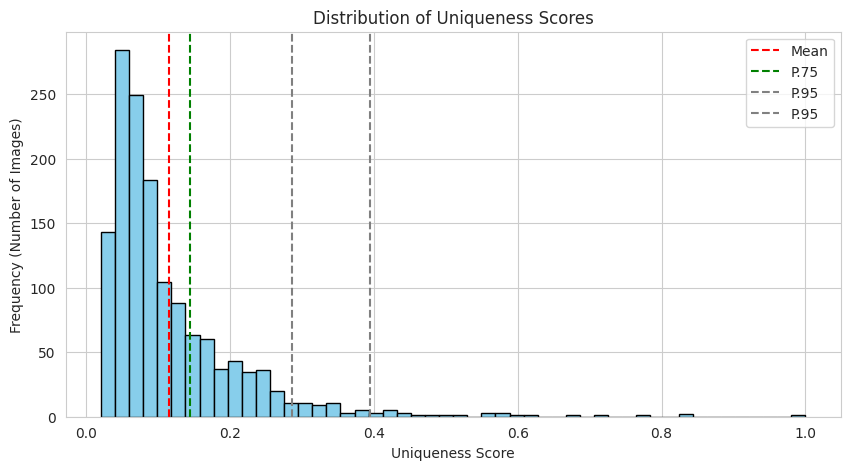

Length of the uniqueness image size list for the given partition:46
Percentile choosen:97.0
number of images:43
Budget Allocation: Uniqueness=43, KMeans=99
Final Consolidated Subset Size: 147
Computing Projections for final visualization...


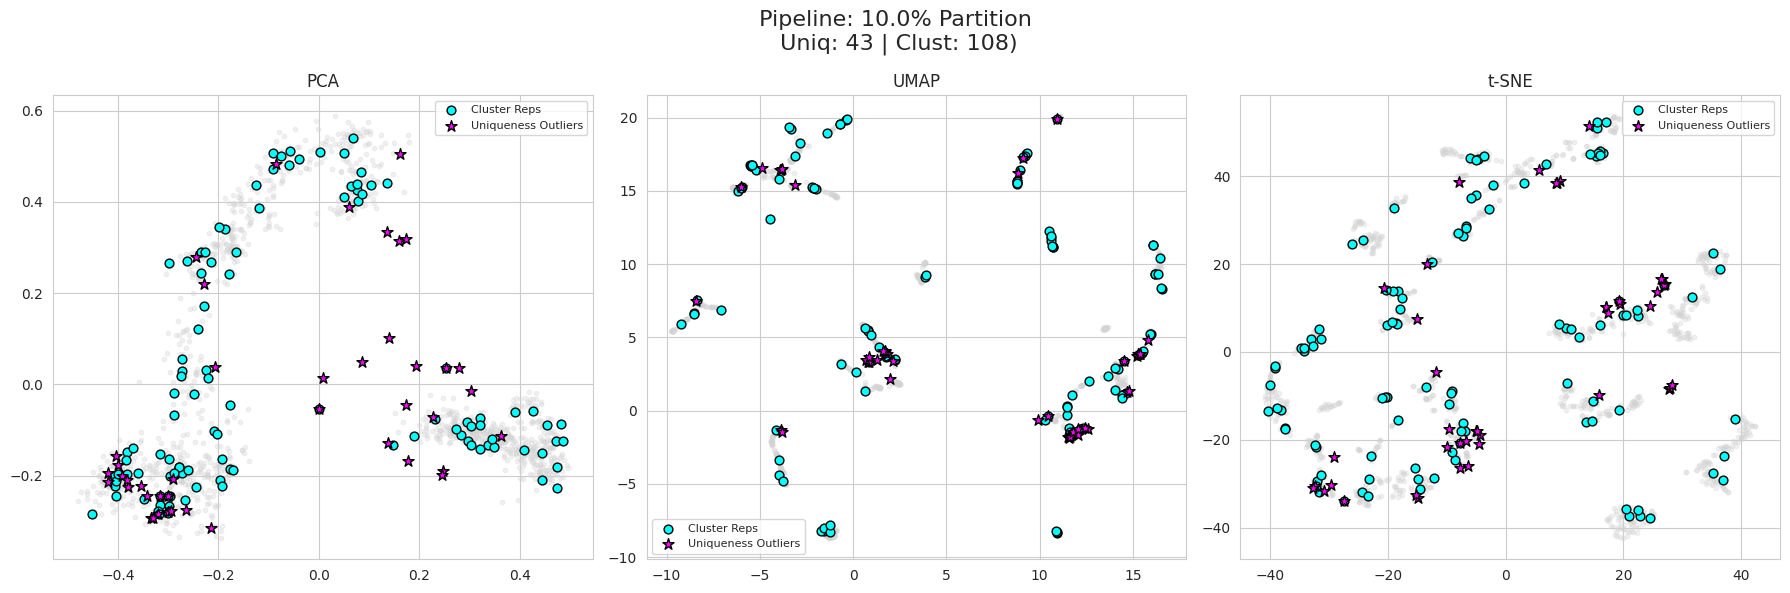

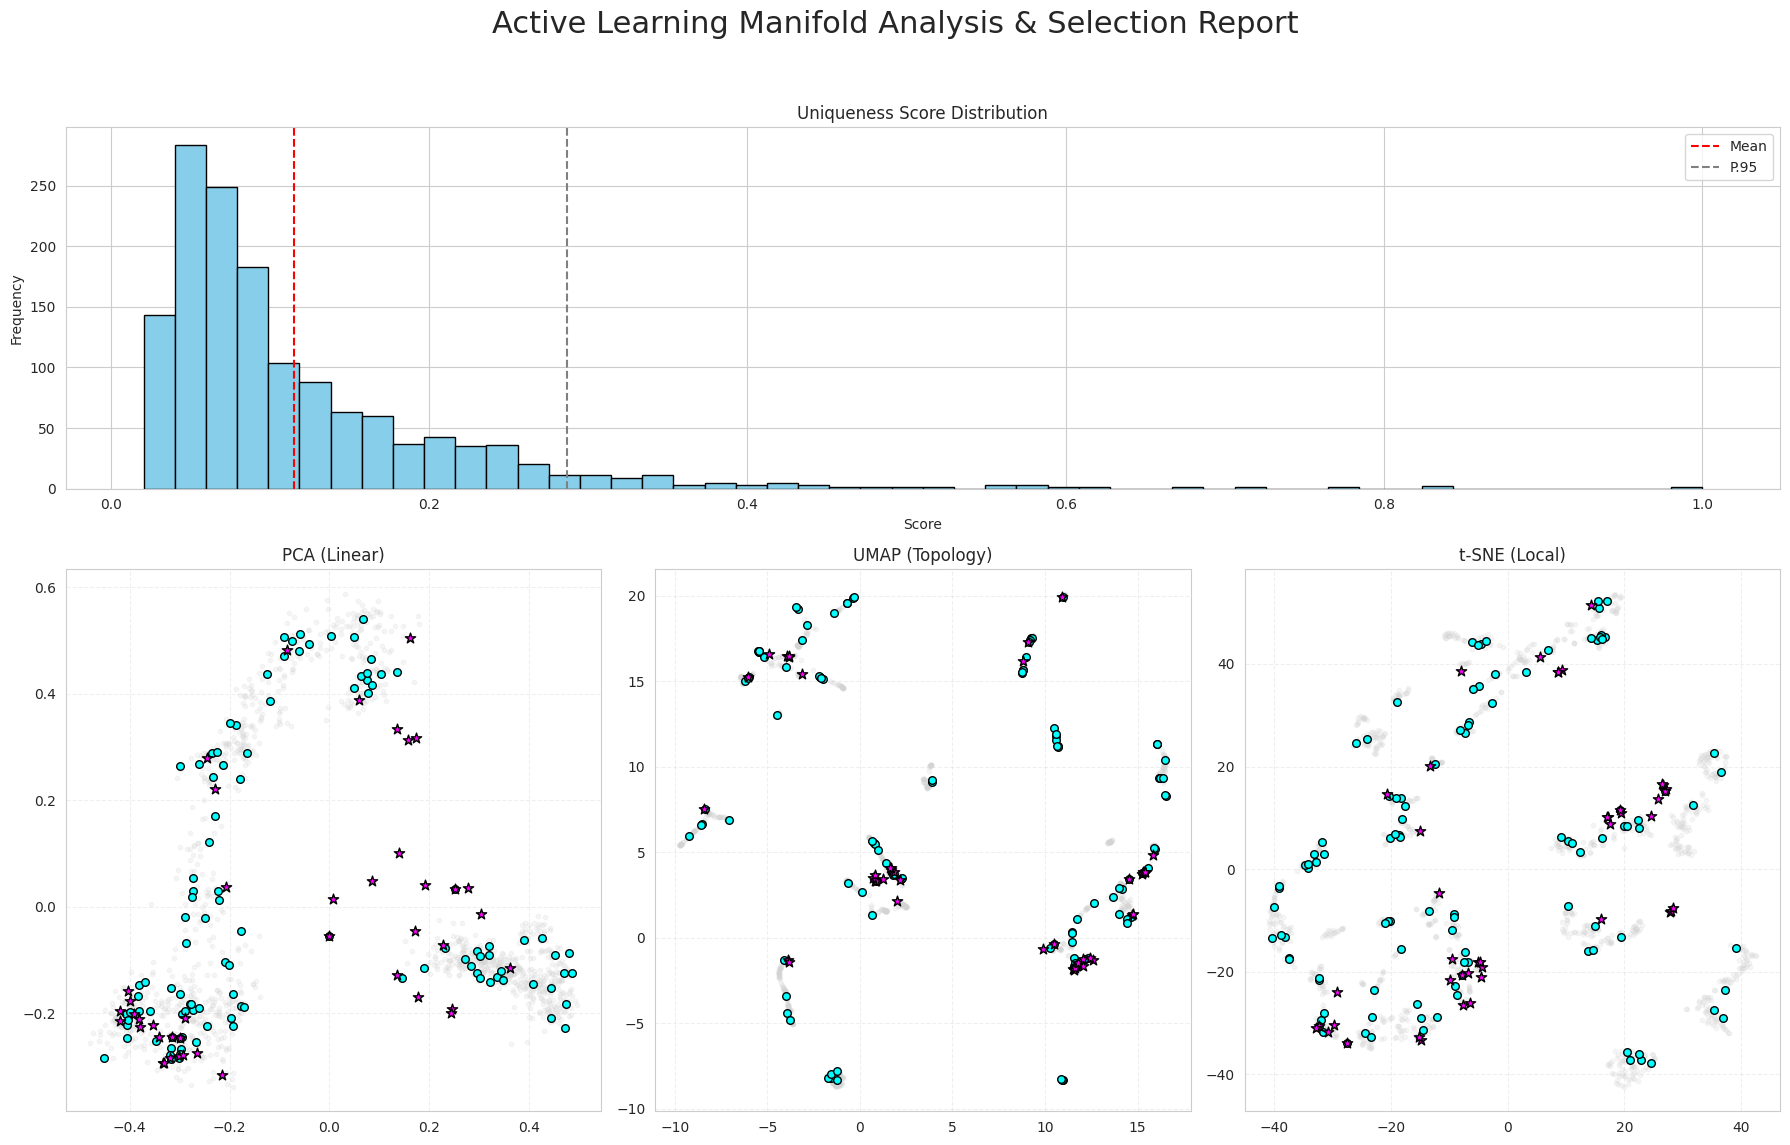

Report saved successfully as AL_Selection_Seed_41.png


In [122]:
# Run the consolidate pipeline
final_al_indices = active_learning_pipeline(
    wp_train_emb_norm,
    partition_size=0.10,            # 10% of dataset
    ratio_cluster_uniqueness=0.33,   # Half from clusters, half from outliers
    n_clusters=12,
    seed_number=41
)

# Convert back to FiftyOne IDs
#final_selection_ids = [wp_train_ids[i] for i in final_al_indices]
#dataset.select(final_selection_ids).tag_samples("Consolidated_AL_Selection_v1")

Approach 2 — **HDBSCAN + Uniqueness**

```bash
Stage 1 — Representative samples (HDBSCAN):

Reduce dimensionality with UMAP to ~15–30 components (min_dist=0.0) before clustering.
This is required because HDBSCAN struggled in high-dimensional spaces (1024d) likely due to the curse of dimensionality.
Run HDBSCAN on the reduced embeddings — K is discovered automatically from data density
Select the n_per_cluster most representative points per cluster (highest membership probability)
Noise points (label = -1) can be or not treated as high-uniqueness candidates in Stage 2

Stage 2 — Diverse samples (Uniqueness):

Uniqueness is computed on the original full embeddings (not the reduced ones)
Noise points are prioritised with a score boost before ranking

In [ ]:
import hdbscan


def reduce_embeddings(embeddings_norm: np.ndarray,
                      n_components: int = 30,
                      random_state: int = 42) -> np.ndarray:
    """
    Reduce high-dimensional embeddings before clustering.
    n_components=30 preserves structure well while being low enough
    for HDBSCAN to find meaningful density differences.
    """
    reducer = umap.UMAP(
        n_components = n_components,
        metric       = "cosine",
        random_state = random_state,
        n_neighbors  = 15,
        min_dist     = 0.0,    # 0.0 preserves local structure better for clustering
    )
    return reducer.fit_transform(embeddings_norm)

    
def select_hdbscan_representatives(
    embeddings_norm: np.ndarray,
    min_cluster_size: int = 10,
    min_samples: int      = 5,
    n_per_cluster: int    = 1,      
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Cluster with HDBSCAN then select the `n_per_cluster` most representative
    points per cluster (highest membership probability = closest to dense core).

    If a cluster has fewer than n_per_cluster members, all its members
    are selected.
    """
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size         = min_cluster_size,
        min_samples              = min_samples,
        metric                   = "euclidean",
        cluster_selection_method = "eom",
        prediction_data          = True,
    )
    clusterer.fit(embeddings_norm)
    labels = clusterer.labels_
    probs  = clusterer.probabilities_

    unique_clusters = sorted(set(labels) - {-1})
    n_clusters      = len(unique_clusters)

    representative_indices = []
    for c in unique_clusters:
        cluster_mask    = labels == c
        cluster_indices = np.where(cluster_mask)[0]
        cluster_probs   = probs[cluster_mask]

        # take top-n by membership probability, capped at cluster size
        n_pick     = min(n_per_cluster, len(cluster_indices))
        top_local  = np.argsort(cluster_probs)[::-1][:n_pick]
        representative_indices.extend(cluster_indices[top_local].tolist())

    print(f"      → HDBSCAN found {n_clusters} clusters, "
          f"{(labels == -1).sum()} noise points")

    return np.array(representative_indices), labels, probs

def select_unique(
    embeddings_norm: np.ndarray,
    already_selected: np.ndarray,
    labels: np.ndarray,
    n_unique: int,
    weights: list = None,
    prioritise_noise: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Select the most unique images from the pool not yet selected.
 
    If `prioritise_noise=True`, HDBSCAN noise points (label == -1) are scored
    first and sorted to the top of the pool before uniqueness ranking, since
    they are by definition the least cluster-like (most isolated) points.
 
    Returns
    -------
    unique_indices : (n_unique,) global indices
    unique_scores  : corresponding uniqueness scores
    """
    all_indices  = np.arange(len(embeddings_norm))
    pool_mask    = np.ones(len(embeddings_norm), dtype=bool)
    pool_mask[already_selected] = False
    pool_indices = all_indices[pool_mask]
 
    pool_embeddings = embeddings_norm[pool_indices]
    scores          = compute_weighted_uniqueness(pool_embeddings, weights)
 
    # Boost noise points: add 1.0 to push them above all non-noise scores
    if prioritise_noise:
        pool_labels = labels[pool_indices]
        noise_boost = (pool_labels == -1).astype(float)
        scores      = scores + noise_boost   # noise points get scores in [1, 2]
 
    top_local    = np.argsort(scores)[::-1][:n_unique]
    return pool_indices[top_local], scores[top_local]

In [ ]:
def plot_clusters(umap_2d: np.ndarray,
                  labels: np.ndarray):
    """
    Simple cluster visualisation — no selection overlay.
    Useful to inspect HDBSCAN output before running selection.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    unique_labels = sorted(set(labels) - {-1})
    n_clusters    = len(unique_labels)
    cmap          = plt.get_cmap("tab20", max(n_clusters, 1))

    # noise points
    noise_mask = labels == -1
    if noise_mask.any():
        ax.scatter(
            umap_2d[noise_mask, 0], umap_2d[noise_mask, 1],
            c="lightgrey", s=14, alpha=0.4, linewidths=0,
            zorder=1, label=f"Noise ({noise_mask.sum()})",
        )

    # one colour per cluster, annotate cluster id at centroid
    for i, c in enumerate(unique_labels):
        mask = labels == c
        ax.scatter(
            umap_2d[mask, 0], umap_2d[mask, 1],
            color=cmap(i), s=18, alpha=0.6, linewidths=0,
            zorder=2, label=f"Cluster {c} ({mask.sum()})",
        )
        # cluster label annotation at median position
        cx, cy = np.median(umap_2d[mask, 0]), np.median(umap_2d[mask, 1])
        ax.text(cx, cy, str(c), fontsize=9, fontweight="bold",
                ha="center", va="center",
                color="white",
                bbox=dict(boxstyle="round,pad=0.2", fc=cmap(i), ec="none", alpha=0.8))

    ax.set_title(
        f"HDBSCAN clusters  |  {n_clusters} clusters  |  "
        f"{noise_mask.sum()} noise points  |  {len(labels)} total images",
        fontsize=13, fontweight="bold",
    )
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(loc="center right", fontsize=8, ncol=2)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    fig.show()

def plot_selection(umap_2d: np.ndarray,
                   labels: np.ndarray,
                   representative_indices: np.ndarray,
                   unique_indices: np.ndarray,):
    """
    Scatter plot:
      • Clustered points coloured by cluster id
      • Noise points shown in light grey
      • Representatives marked with a star ★
      • Unique/noise samples marked with a diamond ◆
    """
    fig, ax = plt.subplots(figsize=(12, 8))
 
    unique_labels = sorted(set(labels) - {-1})
    n_clusters    = len(unique_labels)
    cmap          = plt.get_cmap("tab20", max(n_clusters, 1))
 
    # — noise points (grey background)
    noise_mask = labels == -1
    if noise_mask.any():
        ax.scatter(
            umap_2d[noise_mask, 0], umap_2d[noise_mask, 1],
            c="lightgrey", s=14, alpha=0.4, linewidths=0,
            zorder=1, label=f"Noise ({noise_mask.sum()})",
        )
 
    # — clustered points coloured by cluster
    for i, c in enumerate(unique_labels):
        mask = labels == c
        ax.scatter(
            umap_2d[mask, 0], umap_2d[mask, 1],
            color=cmap(i), s=18, alpha=0.45, linewidths=0,
            zorder=2,
        )
 
    # — Stage 1: representatives (stars)
    ax.scatter(
        umap_2d[representative_indices, 0],
        umap_2d[representative_indices, 1],
        marker="*", s=220, color="white",
        edgecolors="black", linewidths=0.6,
        label=f"Representatives ({len(representative_indices)})",
        zorder=4,
    )
 
    # — Stage 2: unique samples (diamonds)
    ax.scatter(
        umap_2d[unique_indices, 0], umap_2d[unique_indices, 1],
        marker="D", s=60, color="crimson",
        edgecolors="black", linewidths=0.4,
        label=f"Unique / noise samples ({len(unique_indices)})",
        zorder=4,
    )
 
    total = len(representative_indices) + len(unique_indices)
    ax.set_title(
        f"HDBSCAN + Uniqueness  "
        f"({total} / {len(umap_2d)} images  |  {n_clusters} clusters found)",
        fontsize=13, fontweight="bold",
    )
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(loc="center right", fontsize=9)
    ax.grid(True, alpha=0.2)
 
    plt.tight_layout()
    fig.show()